# Eval for Moralization Detection (binary classification)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

#root_dir = Path('/work/moralization')
root_dir = Path.home() / 'scratch/projects/moralization'

In [3]:
import sys

sys.path.append((root_dir / 'src/open_models').as_posix())

load gold annotations

In [4]:
import json

with (root_dir / 'data/testset_LREC2026.json').open('r') as f:
    data = json.load(f)
data = {d['text_id']: d for d in data}
len(data)

1734

load predictions

In [6]:
import json

with (root_dir / 'data/predictions_20250930.json').open('r') as f:
    p = json.load(f)
predictions = {k: {d['text_id']: d for d in v} for k, v in p.items()}
len(predictions)

70

In [7]:
models = ['claude', 'gpt-5', 'cohere', 'llama', 'mistral']

experiments = [
    'basic_json_0shot',
    'cot_json_0shot',
    'cot_json-explain_0shot',
    'cot_json_10shot',
    'cot_json-explain_10shot',
    'manual_json_0shot',
    'manual_json-explain_0shot',
]

In [8]:
def build_ensemble(preds, input_type, output_type, n_shot, split, text_ids):
    pred = {}
    for text_id in text_ids:
        votes = [preds[f'{input_type}_{output_type}_{n_shot}_{model}_{split}'][text_id] for model in models]
        pred[text_id] = True if sum([int(vote) for vote in votes]) > (len(votes) // 2) else False
    return pred

In [9]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix

def compute_scores(true: list, pred: list):
    score = {'precision': {}, 'recall': {}, 'f1-score': {}}
    score['accuracy'] = accuracy_score(true, pred)
    for avg in ['micro', 'macro', 'weighted', 'binary']:
        p, r, f, n = precision_recall_fscore_support(true, pred, average=avg)
        score['precision'][avg] = p
        score['recall'][avg] = r
        score['f1-score'][avg] = f
    tn, fp, fn, tp = confusion_matrix(true, pred).ravel()
    score['confusion_matrix'] = {
        'true_negatives': int(tn), 
        'false_positives': int(fp), 
        'false_negatives': int(fn), 
        'true_positives': int(tp)
    }
    return score

In [10]:
scores = {}
preds = {}
for split in ['test-150', 'test']:
    text_ids = [text_id for text_id, d in data.items() if d['split'] == split] # and d['is_valid']
    true = [data[text_id]['contains_moralization'] for text_id in text_ids]
    for input_type in ['basic', 'cot', 'manual']:
        for output_type in ['json', 'json-explain']:
            for n_shot in ['0shot', '10shot']:
                if f'{input_type}_{output_type}_{n_shot}' in experiments:
                    # lookup model outputs
                    for model in models:
                        name = f'{input_type}_{output_type}_{n_shot}_{model}_{split}'
                        preds[name] = {text_id: predictions[name][text_id]['output']['moralisierung']['enthaelt_moralisierung'] for text_id in text_ids}
                        pred = [preds[name][text_id] for text_id in text_ids]
                        assert len(true) == len(pred), (len(true), len(pred))
                        scores[name] = compute_scores(true, pred)
                    # ensemble
                    name = f'{input_type}_{output_type}_{n_shot}_ensemble_{split}'
                    preds[name] = build_ensemble(preds, input_type, output_type, n_shot, split, text_ids)
                    pred = [preds[name][text_id] for text_id in text_ids]
                    assert len(true) == len(pred), (len(true), len(pred))
                    scores[name] = compute_scores(true, pred)
len(scores), len(preds)

(84, 84)

In [11]:
text_ids = [text_id for text_id, d in data.items() if d['split'] in ['test-150', 'test']] # and d['is_valid']
true = [data[text_id]['contains_moralization'] for text_id in text_ids]
for input_type in ['basic', 'cot', 'manual']:
    for output_type in ['json', 'json-explain']:
        for n_shot in ['0shot', '10shot']:
            if f'{input_type}_{output_type}_{n_shot}' in experiments:
                # lookup model outputs
                for model in models:
                    p = {}
                    for split in ['test-150', 'test']:
                        n = f'{input_type}_{output_type}_{n_shot}_{model}_{split}'
                        p.update({text_id: predictions[n][text_id]['output']['moralisierung']['enthaelt_moralisierung'] for text_id in text_ids if text_id in predictions[n]})
                    name = f'{input_type}_{output_type}_{n_shot}_{model}_all'
                    preds[name] = p
                    pred = [preds[name][text_id] for text_id in text_ids]
                    assert len(true) == len(pred), (len(true), len(pred))
                    scores[name] = compute_scores(true, pred)
                # ensemble
                name = f'{input_type}_{output_type}_{n_shot}_ensemble_all'
                preds[name] = build_ensemble(preds, input_type, output_type, n_shot, 'all', text_ids)
                pred = [preds[name][text_id] for text_id in text_ids]
                assert len(true) == len(pred), (len(true), len(pred))
                scores[name] = compute_scores(true, pred)
len(scores), len(preds)

(126, 126)

In [13]:
with (root_dir / 'data/scores_20250930.json').open('w') as f:
    json.dump(scores, f, indent=4)
with (root_dir / 'data/preds_20250930.json').open('w') as f:
    json.dump(preds, f, indent=4)

In [12]:
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook"

def get_score(score, avg):
    if isinstance(score, float):
        return score
    elif isinstance(score, dict) and avg in score:
        return score[avg]
    else:
        raise ValueError

In [13]:
model_legend = {
    'claude': 'claude-3-5-haiku-20241022',
    'gpt-5': 'gpt-5-mini-2025-08-07',
    'cohere': 'c4ai-command-a-03-2025 (111B)',
    'llama': 'Llama-4-Scout-17B-16E-Instruct (109B)',
    'mistral': 'Mistral-Small-3.2-24B-Instruct-2506',
    #'openai': 'openai_gpt-oss-120b',
    #'qwen': 'Qwen Qwen3-30B-A3B-Instruct-2507',
    'ensemble': 'ensemble (majority vote)'
}

In [23]:
def plot(scores, split, metric, avg='macro'):
    
    data = []
    for model, legend in model_legend.items():
        x=['<br>'.join(experiment.split('_')) for experiment in experiments]
        y=[get_score(scores[f'{experiment}_{model}_{split}'][metric], avg) for experiment in experiments]
        data.append(go.Bar(x=x, y=y, name=legend, text=[f'{d:.04f}' for d in y]))
            

    metric_name = metric if metric == 'accuracy' else f'{metric} ({avg})'
    split_name = 'test-150 + test' if split == 'all' else split
    layout = go.Layout(
        title_text=f'Moralization Detection | {split_name}',
        title_y=0.95,
        xaxis_title_text='Prompt Types',
        yaxis_title_text=metric_name,
        yaxis_range=[0, 1],
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="right",
            x=1,
            #maxheight=0.1
        )
    )
    
    fig = go.Figure(data=data, layout=layout)
    fig.write_image(root_dir / f"results/img/{split}_{metric}.png", width=1000, height=400) 
    fig.show()

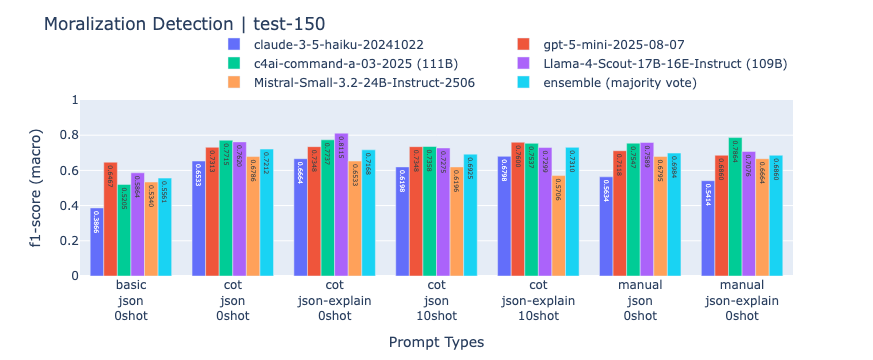

In [24]:
plot(scores, split='test-150', metric='f1-score', avg='macro')

In [25]:
plot(scores, split='test', metric='f1-score', avg='macro')

In [26]:
plot(scores, split='all', metric='f1-score', avg='macro')

In [27]:
def metrics_plot(scores, input_type, output_type, n_shot, split, avg='macro'):

    metrics = ['accuracy', 'precision', 'recall', 'f1-score']

    name = f'{input_type}_{output_type}_{n_shot}'
    data = []
    for model, legend in model_legend.items():
        x = [m if m == 'accuracy' else f'{m} ({avg})' for m in metrics]
        y = [get_score(scores[f'{name}_{model}_{split}'][metric], avg) for metric in metrics]
        assert len(x) == len(y)
        data.append(go.Bar(x=x, y=y, name=legend, text=[f'{d:.04f}' for d in y]))
    
    layout = go.Layout(
        title_text=f'Moralization Detection | {name} {split}',
        xaxis_title_text='Metrics',
        yaxis_title_text='Score',
        yaxis_range=[0, 1],
    )
    
    fig = go.Figure(data=data, layout=layout)
    fig.write_image(root_dir / f"results/img/metrics_{name}_{split}.png", width=1000, height=400) 
    fig.show()

In [28]:
for split in ['test-150', 'test']:
    for input_type in ['basic', 'cot', 'manual']:
        for output_type in ['json', 'json-explain']:
            for n_shot in ['0shot', '10shot']:
                if f'{input_type}_{output_type}_{n_shot}' in experiments:
                    metrics_plot(scores, input_type, output_type, n_shot, split, avg='macro')

In [29]:
def confusion_matrix_plot(scores, input_type, output_type, n_shot, split):
    confusion_matrix = ['true_positives', 'true_negatives', 'false_positives', 'false_negatives']
    name = f'{input_type}_{output_type}_{n_shot}'

    data = []
    for model, legend in model_legend.items():
        y = [scores[f'{name}_{model}_{split}']['confusion_matrix'][cm] for cm in confusion_matrix]
        assert len(confusion_matrix) == len(y)
        data.append(go.Bar(x=confusion_matrix, y=y, name=legend, text=y))

    max_count = 100 if split == 'test-150' else 1200
    split_name = 'test-150 + test' if split == 'all' else split
    layout = go.Layout(
        title_text=f'Moralization Detection | {name} | {split_name}',
        xaxis_title_text='Confusion Matrix',
        yaxis_title_text='Count',
        yaxis_range=[0, max_count],
    )
    
    fig = go.Figure(data=data, layout=layout)
    fig.write_image(root_dir / f"results/img/confusion_matrix_{name}_{split}.png", width=1000, height=400) 
    fig.show()

In [ ]:
for split in ['all']: #, 'test-150'
    for input_type in ['basic', 'cot', 'manual']:
        for output_type in ['json', 'json-explain']:
            for n_shot in ['0shot', '10shot']:
                if f'{input_type}_{output_type}_{n_shot}' in experiments:
                    confusion_matrix_plot(scores, input_type, output_type, n_shot=n_shot, split=split)

In [22]:
split = 'all'
for model in models + ['ensemble']:
    print(f'|{model}|acc|pre|rec| f1|time[h]|')
    print(f'|:------|--:|--:|--:|--:|------:|')
    for input_type in ['basic', 'cot', 'manual']:
        for output_type in ['json', 'json-explain']:
            for n_shot in ['0shot', '10shot']:
                experiment = f'{input_type}_{output_type}_{n_shot}'
                if experiment in experiments:
                    name = f'{experiment}_{model}_{split}'
                    a = get_score(scores[name]['accuracy'], avg='macro')
                    p = get_score(scores[name]['precision'], avg='macro')
                    r = get_score(scores[name]['recall'], avg='macro')
                    f = get_score(scores[name]['f1-score'], avg='macro')
                    t = 0.0
                    if model not in ['claude', 'ensemble']:
                        for s in ['test', 'test-150']:
                            t += sum([p['generation_time'] if isinstance(p['generation_time'], float) else 0.0 for _, p in predictions[f'{experiment}_{model}_{s}'].items()]) / 3600
                    print(f'|{experiment}_{model}|{a:.4f}|{p:.4f}|{r:.4f}|{f:.4f}|{t:.2f}|')
    print()

|claude|acc|pre|rec| f1|time[h]|
|:------|--:|--:|--:|--:|------:|
|basic_json_0shot_claude|0.3922|0.6654|0.5589|0.3591|0.00|
|cot_json_0shot_claude|0.6805|0.7209|0.7500|0.6772|0.00|
|cot_json_10shot_claude|0.6719|0.7214|0.7473|0.6695|0.00|
|cot_json-explain_0shot_claude|0.7105|0.7330|0.7692|0.7049|0.00|
|cot_json-explain_10shot_claude|0.7042|0.7308|0.7656|0.6992|0.00|
|manual_json_0shot_claude|0.5554|0.6913|0.6715|0.5542|0.00|
|manual_json-explain_0shot_claude|0.5865|0.6987|0.6926|0.5864|0.00|

|gpt-5|acc|pre|rec| f1|time[h]|
|:------|--:|--:|--:|--:|------:|
|basic_json_0shot_gpt-5|0.6113|0.7058|0.7095|0.6113|17.05|
|cot_json_0shot_gpt-5|0.7641|0.7336|0.7595|0.7407|16.73|
|cot_json_10shot_gpt-5|0.7647|0.7341|0.7599|0.7413|17.20|
|cot_json-explain_0shot_gpt-5|0.7509|0.7238|0.7529|0.7296|16.79|
|cot_json-explain_10shot_gpt-5|0.7682|0.7381|0.7650|0.7454|21.32|
|manual_json_0shot_gpt-5|0.7491|0.7445|0.7854|0.7384|18.85|
|manual_json-explain_0shot_gpt-5|0.7457|0.7439|0.7850|0.7357|20.45|
